## Middleware
Middleware provides a way to more tightly control what happens inside the agent. Middleware is useful for the following:
* Tracking agent behavior with logging, analytics, and debugging.
* Transforming prompts, tool selection, and output formatting
* Adding retries, fallbacks, and early termination logic.
* Applying rate limits, guardrails and PII detection.

Middleware exposes hooks to trigger some checks.
There are built-in middleware as well. e.g. Summarization, Human In the Feedback etc.


In [2]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [3]:
os.environ["OPENAI_API_KEY"] = os.getenv("API_KEY_OPENAI")

### Summarization MiddleWare
Automatically summarize conversation history when approaching token limits, preservin recent messages while compressing older context. Summarization is useful for the following.


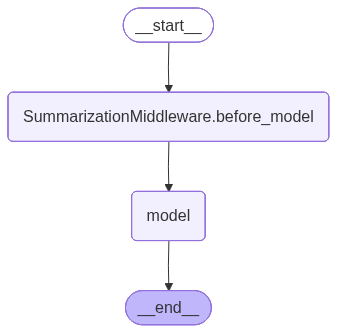

In [9]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langchain.messages import HumanMessage, SystemMessage
from langgraph.checkpoint.memory import InMemorySaver

agent = create_agent(
    model="gpt-4o-mini",
    checkpointer=InMemorySaver(),
    middleware=[
        SummarizationMiddleware(
            model="gpt-4o-mini",
            trigger=("messages", 10),
            keep=("messages", 4)
        )
    ]
)
agent

In [5]:
# Create a thread
config = {"configurable": { "thread_id":"test_1" }}

In [12]:
questions = [
    "What is 2+2",
    "What is 10 * 2",
    "What is 100 ^ 10",
    "What is -1-1",
    "What is 5 + 5 - 5",
    "What is 2 - 3 * (1+2)"
]
for q in questions:
    response = agent.invoke({"messages": [HumanMessage(q)]}, config)
    print(f"Messages: {response['messages']}")
    print(f"Messages Length: {len(response['messages'])}")

Messages: [HumanMessage(content='Here is a summary of the conversation to date:\n\n## SESSION INTENT\nThe user is asking basic arithmetic questions to confirm the correctness of various mathematical operations.\n\n## SUMMARY\nThe user requested solutions for several mathematical expressions: \n- 2 + 2 equals 4.\n- 10 * 2 equals 20.\n- 100 raised to the power of 10 (100^10) equals 10,000,000,000,000,000,000,000,000,000,000,000, which can also be expressed as \\(10^{20}\\). \nThe user subsequently asked for the result of -1 - 1, which equals -2.\n\n## ARTIFACTS\nNone.\n\n## NEXT STEPS\nNone.', additional_kwargs={'lc_source': 'summarization'}, response_metadata={}, id='c0b5f2f6-c3bf-4ed2-9d35-ff6103c6876f'), AIMessage(content='100 ^ 10 equals 10,000,000,000,000,000,000,000,000,000,000,000, which can also be expressed as \\(10^{20}\\).', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 42, 'prompt_tokens': 231, 'total_tokens': 273, 'completion_to

### Using TokenSize to Summarize Messages

In [13]:
from langchain.tools import tool


In [16]:
@tool
def search_hotels(city: str) -> str:
    """ Search Hotels """
    return f"""Hotels in {city}:
    1. Grand Hotel - 5 start, $350/night, spa, pool, gym
    2. City Inn - 4 start, $180/night, business center
    3. Budget Inn - 3 start, $75/night, free wifi
    """

agent = create_agent(
    model="gpt-4o-mini",
    tools=[search_hotels],
    checkpointer=InMemorySaver(),
    middleware=[
        SummarizationMiddleware(model="gpt-4o-mini",
         trigger=("tokens", 550),
         keep=("tokens", 200)
        )
    ]
)
config = {"configurable": {"thread_id": "test-1"}}

# Token Counter
def count_tokens(messages):
    total_chars = sum(len(str(m.content)) for m in messages)
    return total_chars // 4

In [18]:
# Running for different cities
cities = ['Paris', 'London', 'Tokyo', 'New York', 'Dubai']
for city in cities:
    response = agent.invoke(
        {"messages" : [HumanMessage(content=f"Find hotels in {city}")]},
        config=config
    )
    tokens = count_tokens(response["messages"])
    print(f"{city} - {tokens} tokens, {len(response['messages'])} messages")
    print(f"{(response['messages'])}")

Paris - 403 tokens, 5 messages
[HumanMessage(content="Here is a summary of the conversation to date:\n\n## SESSION INTENT\nThe user's primary goal is to find hotels in various cities, specifically starting with Paris, London, Tokyo, New York, and now Dubai.\n\n## SUMMARY\nThe user requested hotel options in several cities: Paris, London, Tokyo, and New York. For each city, the AI provided a list of hotels along with details such as ratings, prices, and amenities. The hotels mentioned include:\n- Paris: Grand Hotel, City Inn, Budget Inn\n- London: Grand Hotel, City Inn, Budget Inn\n- Tokyo: Grand Hotel, City Inn, Budget Inn\n- New York:\n  1. **Grand Hotel** - 5 stars, $350/night, spa, pool, gym\n  2. **City Inn** - 4 stars, $180/night, business center\n  3. **Budget Inn** - 3 stars, $75/night, free Wi-Fi\nThe session continued with the user asking for hotels in Dubai, for which the AI provided a list:\n1. **Grand Hotel** - 5 stars, $350/night, spa, pool, gym\n2. **City Inn** - 4 stars,

### Human In the Loop Middleware
Pause agent execution for human approval, editing or rejection of tool calls before they execute. Human-in-the-loop is useful for following:
* High stakes operations requiring human pprocal
* Compliance workfloes where human oversight is mandatory
* Long running conversations where human feedback guides the agents.

In [22]:
from langchain.agents.middleware import HumanInTheLoopMiddleware
@tool
def read_email_tool(email_id: str):
    """ Mock function to read an email by its Id"""
    return f"Email content for ID: {email_id}"
@tool
def send_email_tool(recipient: str, subject: str, body: str) -> str:
    """Mock function to send an email."""
    return f"Email sent to {recipient} with subject {subject}"

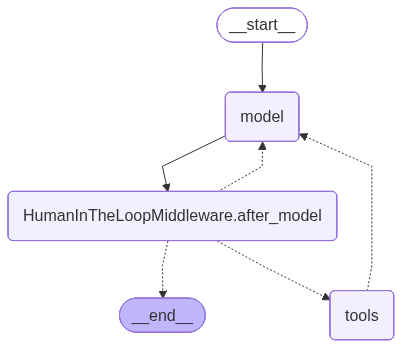

In [23]:
agent = create_agent(
    model="gpt-4o-mini",
    tools=[read_email_tool, send_email_tool],
    checkpointer=InMemorySaver(),
    middleware=[HumanInTheLoopMiddleware(interrupt_on={
        "send_email_tool": {"allowed_decisions": ["approve", "edit", "reject"]},
        "read_email_tool": False
        })
    ]
)
agent

In [ ]:
config={"configurable": {"thread_id": "test-approve"}}
# Step1: Request an approval
result = agent.invoke(
    {"messages": [HumanMessage(content="send email to john@test.com with subject 'Hello' and body 'Hey.How are you?'")]},
    config=config
)

In [30]:
result

{'messages': [HumanMessage(content="send email to john@test.com with subject 'Hello' and body ' How are you?'", additional_kwargs={}, response_metadata={}, id='e32a3aaf-8dca-4dfb-9793-079b9530c8d5'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 28, 'prompt_tokens': 97, 'total_tokens': 125, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_bd4be55b21', 'id': 'chatcmpl-DEeuVMLBZXlzD2Ex6bbjCj7EmEsKj', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019caa73-8347-7932-b37a-66b43c6b956a-0', tool_calls=[{'name': 'send_email_tool', 'args': {'recipient': 'john@test.com', 'subject': 'Hello', 'body': ' How are you?'}, 'id': 'call_qDIXzhUQa

In [31]:
#Step2: Grant Approval process
from langgraph.types import Command
if "__interrupt__" in result:
    print("Execution paused. Approving...")
    result = agent.invoke(
        Command(resume={"decisions": [{"type": "approve"}]}),
        config=config
    )
    print(f"Result: {result['messages'][-1].content}")